<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº0 – Generador de señales senoidales
#### HOFFENREICH JULIETA


# Introducción
Durante este trabajo se implementó en Python un generador de señales senoidales que permite parametrizar la amplitud máxima, el valor medio, la frecuencia, la fase, la cantidad de muestras y la frecuencia de muestreo. A partir del uso de dicho generador se analizó el efecto del muestreo sobre señales de diferentes frecuencias, prestando especial atención a la frecuencia de Nyquist y al efecto de aliasing.

Una señal senoidal puede describirse mediante la siguiente expresión:

\begin{equation}
x(t)=dc+vmax\sin(2\pi ft+\phi)
\tag{1}
\end{equation}

donde:

- $vmax$ representa la amplitud máxima de la señal.
- $dc$ representa su valor medio o componente continua.
- $f$ es la frecuencia de la señal, expresada en Hz.
- $\phi$ corresponde a la fase inicial, expresada en radianes.
- $t$ representa el tiempo.

La frecuencia indica la cantidad de ciclos realizados por segundo, mientras que el período $T$ representa el tiempo necesario para completar un ciclo. Ambas magnitudes se relacionan mediante la siguiente expresión:

\begin{equation}
T=\frac{1}{f}
\tag{2}
\end{equation}

Para procesar digitalmente una señal continua es necesario tomar muestras de la misma en determinados instantes de tiempo para lograr "reconstruirla". Dichas muestras se toman con una frecuencia de muestreo $f_s$, que indica la cantidad de muestras tomadas por segundo. La inversa de esta frecuencia corresponde al período de muestreo $T_s$, al intervalo de tiempo existente entre dos muestras consecutivas:

\begin{equation}
T_s=\frac{1}{f_s}
\tag{3}
\end{equation}

La elección de la frecuencia de muestreo es fundamental, ya que determina si la señal puede representarse digitalmente sin ambigüedad. De acuerdo con el *teorema de Nyquist-Shannon*, para que una señal pueda ser reconstruida correctamente a partir de sus muestras, la frecuencia de muestreo debe ser mayor que el doble de la frecuencia de la señal:

\begin{equation}
fs > 2f
\tag{4}
\end{equation}

A partir de esta relación se define la *frecuencia de Nyquist*:

\begin{equation}
f_N=\frac{f_s}{2}
\tag{5}
\end{equation}

Aquellas señales cuya frecuencia sea superior a la frecuencia de Nyquist podrían no quedar representadas de la manera esperada luego del muestreo. En estos casos puede aparecer el fenómeno de *aliasing*, por el cual una señal de determinada frecuencia es interpretada, a partir de sus muestras, como una señal de frecuencia diferente. De esta manera, en lugar de visualizar la señal con sus características originales, puede observarse una señal de menor frecuencia. Esto ocurre porque, al no contar con una cantidad suficiente de muestras por ciclo, distintas señales pueden dar lugar a secuencias de muestras equivalentes.

# Análisis y Desarrollo
Para lograr generar una señal senoidal, se implementó la función `mi_funcion_sen`, que recibe como parámetros la amplitud, el valor medio, la frecuencia, la fase, la cantidad de muestras y la frecuencia de muestreo.

El vector temporal se construye considerando intervalos de $T_s=1/f_s$, mientras que los valores de la señal se obtienen evaluando la ecuación (1) para cada instante de tiempo.

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

#%% definciones
fs=1000 # frecuencia de muestreo - hertz
N=1000 #cantidad de muestras

#%% funciones

def mi_funcion_sen(vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    #vmax=amplitud.
    #dc= valor de continua/valor medio
    #ff=frecuencia
    #nn cantidad de muestras
    #ph=fase

    #Creamos el vector de tiempo que comienza en 0, termina en nn/fs y avanza cada 1/fs. 
    tt=np.arange(0, nn/fs, 1/fs)
    #xx calculara el valor de la senal para cada uno de esos tiempos
    xx=dc + vmax * np.sin (2*np.pi*ff*tt +ph)
    
    # hasta acá
    return(tt, xx)



En primer lugar se verificó el funcionamiento de la función utilizando una señal de amplitud $1.5$ V, valor medio nulo, frecuencia de $3$ Hz y fase inicial nula.
Se utilizó una frecuencia de muestreo de $1000$ Hz y un total de $1000$ muestras, por lo que la ventana temporal observada es aproximadamente de un segundo.

Continuando con el código, se generó la primera señal senoidal con los parámetros mencionados:

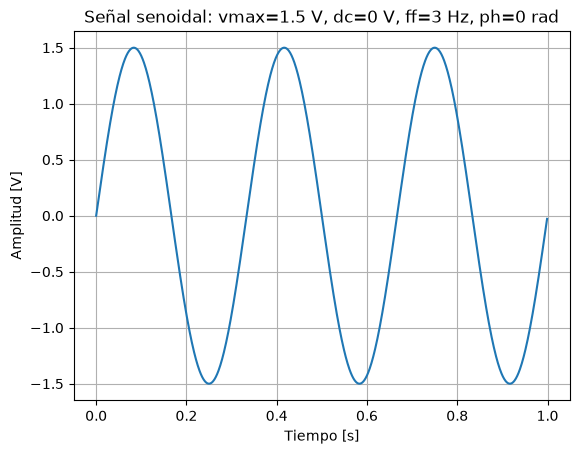

In [9]:
#%% comienzo de mi script 
vmax=1.5
dc=0
ff=3 #poner frec que querramos de la senoidal
#como puse frecuencia 3 mi periodo deberia medir 1/3, entonces en mis n muestras tendria que tener 3 ciclos compeltos
ph=0 #fase 

#cant demuestras y fs ya esta definida

tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff, ph=ph, nn = N, fs = fs)

plt.plot(tt, xx)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal senoidal: vmax={vmax} V, dc={dc} V, ff={ff} Hz, ph={ph} rad')
plt.grid()
plt.show()


Tal como era de esperarse, dentro de la ventana de un segundo observamos 3 ciclos completos, lo cual coincide con que la señal tenga una frecuencia de $3$ Hz.
Además, vemos que se encuentra centrada en $0$ V y alcanza valores máximos y mínimos próximos a $+1.5$ V y $-1.5$ V respectivamente. Esto coincide nuevamente con los valores elegidos para la amplitud y el valor medio, verificando así el correcto funcionamiento del generador.

Posteriormente, para analizar el efecto del muestreo sobre señales de frecuencias más elevadas, se fue modificando únicamente la frecuencia de la señal, mientras que se mantuvieron constantes los siguientes parámetros:
- $f_s=1000$ Hz
- $N=1000$
- $vmax=1$ V
- $dc=0$ V
- $ph=0$

Con una frecuencia de muestreo de $1000$ Hz, la frecuencia de Nyquist resulta:

\begin{equation}
f_N=\frac{1000}{2}=500\text{ Hz}
\tag{6}
\end{equation}

## Señal de 500 Hz


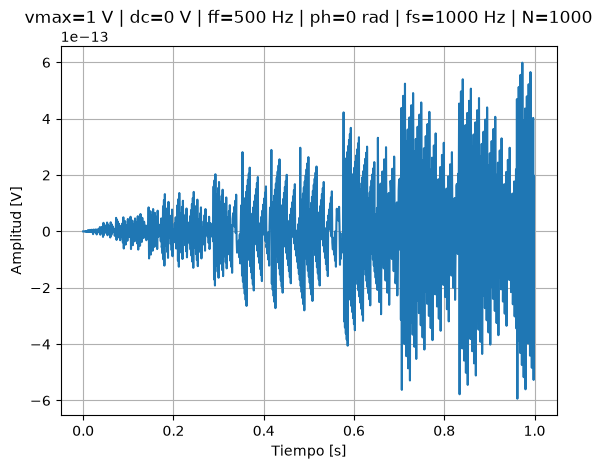

In [6]:
#%% ff = 500 Hz
vmax = 1
dc = 0
ff = 500
ph = 0

tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

plt.figure()
plt.plot(tt, xx)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'vmax={vmax} V | dc={dc} V | ff={ff} Hz | ph={ph} rad | fs={fs} Hz | N={N}')
plt.grid()
plt.show()

Para $f=500$ Hz la frecuencia de la señal coincide exactamente con la frecuencia de Nyquist. 
En este caso se obtienen exactamente dos muestras por período, por lo que se está trabajando con el límite establecido por Nyquist. Sin embargo, esto no garantiza por sí solo una representación adecuada de una señal senoidal para cualquier fase. Como podemos observar en el gráfico, la señal obtenida no presenta la forma senoidal esperada y los valores del eje vertical son muy pequeños, del orden de $10^{-13}$ V.

Si reemplazamos los parámetros utilizados en la expresión de la senoidal, matemáticamente obtenemos que la función es igual a 0 para todo n. 

\begin{equation}
x[n]=\sin\left(2\pi\frac{500}{1000}n\right)
=\sin(\pi n)=0
\tag{7}
\end{equation}

Por lo tanto, idealmente todas las muestras deberían ser nulas. Esto ocurre porque, con la fase utilizada, cada una de las muestras coincide exactamente con un cruce por cero de la señal senoidal.

Sin embargo, en el gráfico observamos valores muy cercanos a cero pero no exactamente iguales a cero. Esto se debe a que en Phyton la función `np.sin(np.pi)` no es exactamente igual a cero. 


## Señal de 999 Hz

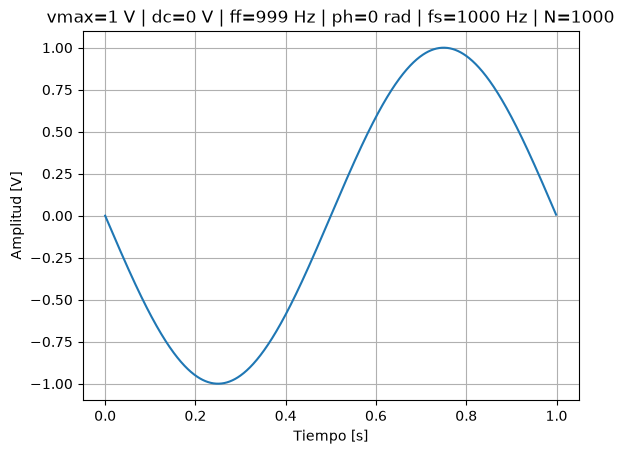

In [7]:
ff = 999
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

plt.figure()
plt.plot(tt, xx)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'vmax={vmax} V | dc={dc} V | ff={ff} Hz | ph={ph} rad | fs={fs} Hz | N={N}')
plt.grid()
plt.show()


Al utilizar una señal de $999$ Hz, el gráfico obtenido se asemeja al de una senoidal de aproximadamente $1$ Hz pero con el signo invertido.
Esto ocurre debido al fenómeno de *aliasing*, ya que la frecuencia de la señal se encuentra por encima de la frecuencia de Nyquist.

Si reemplazamos nuestros valores en la expresión de la señal:
\begin{equation}
x[n]
=\sin\left(2\pi\frac{999}{1000}n\right)
=\sin\left(2\pi n-\frac{2\pi n}{1000}\right)
\tag{8}
\end{equation}

Como el término $2\pi n$ representa una cantidad entera de vueltas completas, debido a la periodicidad del seno, sumarlo o restarlo no modifica el valor de la función. Además, como el seno es una función impar, se cumple que $\sin(-x)=-\sin(x)$. De esta manera:

\begin{equation}
x[n]=-\sin\left(\frac{2\pi n}{1000}\right)
\tag{9}
\end{equation}

Esta expresión corresponde a una señal senoidal de $1$ Hz con signo invertido. Luego del muestreo, la señal de $999$ Hz resulta indistinguible de una senoide de $1$ Hz de signo opuesto. Es decir, los puntos obtenidos al muestrear la senoide de $999$ Hz coinciden con los que se obtendrían para una senoide de $1$ Hz invertida.

## Señal de 1001 Hz

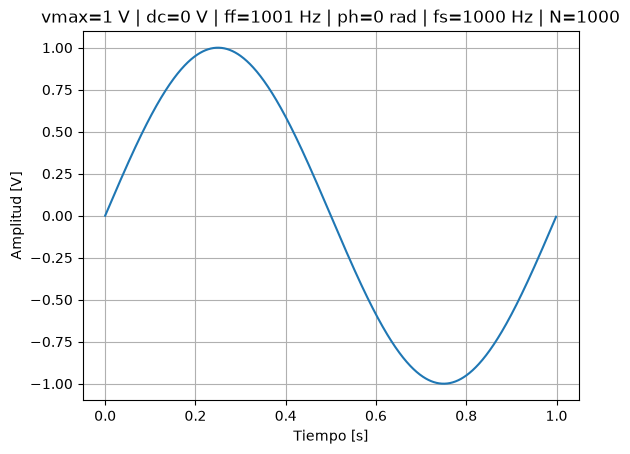

In [8]:
#%% ff = 1001 Hz

ff = 1001

tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

plt.figure()
plt.plot(tt, xx)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'vmax={vmax} V | dc={dc} V | ff={ff} Hz | ph={ph} rad | fs={fs} Hz | N={N}')
plt.grid()
plt.show()

Para una frecuencia de $1001$ Hz vuelve a presentarse el fenómeno de aliasing. A simple vista, el gráfico obtenido se asemeja nuevamente a una señal senoidal de $1$ Hz. 
Reemplazando los valores utilizados en la ecuacion (1):

\begin{equation}
x[n]
=\sin\left(2\pi\frac{1001}{1000}n\right)
=\sin\left(2\pi n+\frac{2\pi n}{1000}\right)
\tag{10}
\end{equation}

Nuevamente, debido a la periodicidad del seno, el término $2\pi n$ no modifica el valor de la función, ya que representa una cantidad entera de períodos completos. Por lo tanto:

\begin{equation}
x[n]=\sin\left(\frac{2\pi n}{1000}\right)
\tag{11}
\end{equation}

La expresión obtenida corresponde exactamente a una señal senoidal de $1$ Hz muestreada a $1000$ Hz. De esta forma, puede comprobarse matemáticamente lo observado en el gráfico: aunque la frecuencia original de la señal es de $1001$ Hz, luego del muestreo resulta indistinguible de una señal de $1$ Hz.


## Señal de 2001 Hz

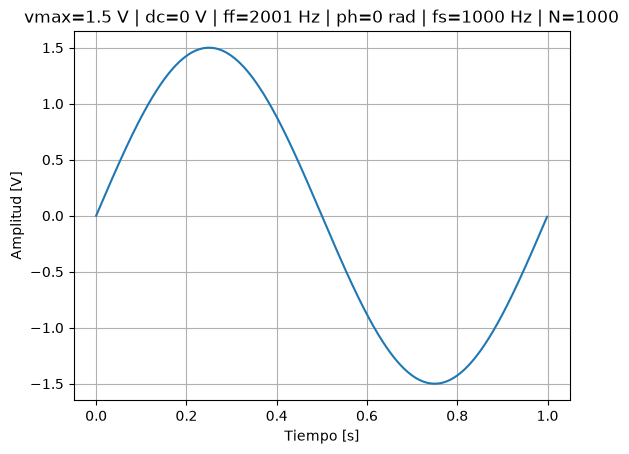

In [11]:
#%% ff = 2001 Hz
ff = 2001
tt, xx = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

plt.figure()
plt.plot(tt, xx)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'vmax={vmax} V | dc={dc} V | ff={ff} Hz | ph={ph} rad | fs={fs} Hz | N={N}')
plt.grid()
plt.show()

Finalmente, al utilizar una frecuencia de $2001$ Hz se observa nuevamente una señal de $1$ Hz. Este resultado también puede comprobarse reemplazando los valores correspondientes en la ecuación de la señal:

\begin{equation}
x[n]
=\sin\left(2\pi\frac{2001}{1000}n\right)
=\sin\left(4\pi n+\frac{2\pi n}{1000}\right)
\tag{12}
\end{equation}

El término $4\pi n$ puede escribirse como:

\begin{equation}
4\pi n=2\pi(2n)
\tag{13}
\end{equation}

Como $n$ es un número entero, $2n$ también lo es. Por lo tanto, $4\pi n$ representa una cantidad entera de vueltas completas y, por periodicidad del seno, no modifica el valor de la función. Así, se obtiene:

\begin{equation}
x[n]=\sin\left(\frac{2\pi n}{1000}\right)
\tag{14}
\end{equation}

Nuevamente se llega a la expresión correspondiente a una señal senoidal de $1$ Hz. 

## Conclusiones

Los experimentos realizados permitieron observar la importancia de la relación entre la frecuencia de una señal y la frecuencia con la que se la está muestreando. En particular, para una frecuencia de muestreo de 1000 Hz se obtuvo una frecuencia de Nyquist de 500 Hz, la cual determino el límite a partir del cual pueden comenzar a aparecer ambigüedades en la representación de las señales.

El caso de 500 Hz permitió observar que trabajar exactamente sobre este límite puede producir una representación ambigua, ya que con fase nula todas las muestras coinciden con los cruces por cero de la señal.

Por otra parte, las señales de $999 Hz$, $1001 Hz$ y $2001 Hz$ mostraron el fenómeno de aliasing. A pesar de poseer frecuencias muy diferentes, luego del muestreo todas se observaron como señales de aproximadamente $1 Hz$. Esto demuestra que distintas señales continuas pueden generar la misma secuencia de muestras cuando no se cumplen adecuadamente las condiciones de muestreo.

Los resultados obtenidos muestran que la elección de la frecuencia de muestreo es fundamental en la adquisición y posterior procesamiento digital de señales.